# House Prices: Exploratory Data Analysis

 Pay your attention that for showing plots from PLOTLY library you should launch the project

In [1]:
import plotly.io as pio
pio.renderers.default = 'colab'

## Imports

In [2]:
import pandas as pd
import plotly.express as px
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import ttest_ind
!pip install catboost
from catboost import CatBoostRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error


[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip


## Goal of my project (Abstract)

My project presents an exploratory data analysis of the Ames Housing Dataset, sourced from Kaggle. The dataset contains information about properties in Ames, Iowa, including physical characteristics, location, and sale price

The main goal of my analysis is to identify which factors have the greatest influence on house pricing. Through statistical analysis and visualization, I examine relationships between price and key features such as living area, overall quality, basement area, and neighborhood. The project also includes hypothesis testing in order to find out some data patterns

##  Description of Dataset

In [3]:
df_old = pd.read_csv('train.csv')
df_old.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [4]:
df_old.shape

(1460, 81)

In [5]:
df_old.columns

Index(['Id', 'MSSubClass', 'MSZoning', 'LotFrontage', 'LotArea', 'Street',
       'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig',
       'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType',
       'HouseStyle', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd',
       'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType',
       'MasVnrArea', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual',
       'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinSF1',
       'BsmtFinType2', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', 'Heating',
       'HeatingQC', 'CentralAir', 'Electrical', '1stFlrSF', '2ndFlrSF',
       'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath',
       'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'KitchenQual',
       'TotRmsAbvGrd', 'Functional', 'Fireplaces', 'FireplaceQu', 'GarageType',
       'GarageYrBlt', 'GarageFinish', 'GarageCars', 'GarageArea', 'GarageQual',
       'GarageCond', 'PavedDrive

In [6]:
df_old.info()

<class 'pandas.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   str    
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   str    
 6   Alley          91 non-null     str    
 7   LotShape       1460 non-null   str    
 8   LandContour    1460 non-null   str    
 9   Utilities      1460 non-null   str    
 10  LotConfig      1460 non-null   str    
 11  LandSlope      1460 non-null   str    
 12  Neighborhood   1460 non-null   str    
 13  Condition1     1460 non-null   str    
 14  Condition2     1460 non-null   str    
 15  BldgType       1460 non-null   str    
 16  HouseStyle     1460 non-null   str    
 17  OverallQual    1460 non-null   int64  
 18  OverallCond    1460

In [7]:
main_cols = ['SalePrice', 'GrLivArea', 'TotalBsmtSF', 'LotArea', 'LotFrontage', 'YearBuilt', 'YrSold', 'Neighborhood', 'GarageType', 'HeatingQC','OverallQual']
df = df_old[main_cols]
df.columns

Index(['SalePrice', 'GrLivArea', 'TotalBsmtSF', 'LotArea', 'LotFrontage',
       'YearBuilt', 'YrSold', 'Neighborhood', 'GarageType', 'HeatingQC',
       'OverallQual'],
      dtype='str')

In [8]:
df.isnull().sum()

SalePrice         0
GrLivArea         0
TotalBsmtSF       0
LotArea           0
LotFrontage     259
YearBuilt         0
YrSold            0
Neighborhood      0
GarageType       81
HeatingQC         0
OverallQual       0
dtype: int64

The dataset was sourced from Kaggle and originally contains 1,460 rows and 81 columns. For this analysis, 11 features were selected covering price, area measurements, location, build year, and property characteristics.
Selected features:

- **SalePrice** — final sale price of the house
- **GrLivArea** — above-ground living area in square feet
- **TotalBsmtSF** — total basement area in square feet
- **LotArea** — total lot area in square feet
- **LotFrontage** — length of the street-facing side of the lot in feet
- **YearBuilt** — year the house was constructed
- **YrSold** — year the house was sold
- **Neighborhood** — physical location within Ames city
- **GarageType** — type of garage
- **HeatingQC** — heating quality and condition
- **OverallQual** — overall material and finish quality, rated 1-10

Two columns contained missing values: LotFrontage had 259 missing entries (17.7% of rows) and GarageType had 81 missing entries (5.5%). All other columns were complete.

## Data Cleanup

In [9]:
df.isnull().sum()

SalePrice         0
GrLivArea         0
TotalBsmtSF       0
LotArea           0
LotFrontage     259
YearBuilt         0
YrSold            0
Neighborhood      0
GarageType       81
HeatingQC         0
OverallQual       0
dtype: int64

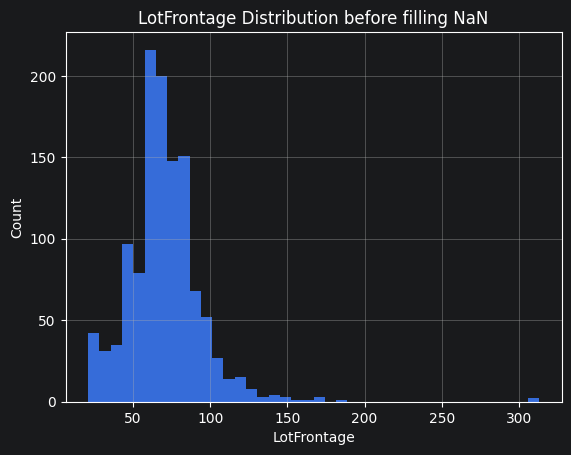

In [10]:
df['LotFrontage'].hist(bins=40)
plt.title('LotFrontage Distribution before filling NaN')
plt.xlabel('LotFrontage')
plt.ylabel('Count')
plt.show()

In [11]:
df['LotFrontage'].skew()

np.float64(2.163569142324884)

In [12]:
df.loc[:,'LotFrontage'] = df['LotFrontage'].fillna(df['LotFrontage'].median())
df.loc[:,'GarageType'] = df['GarageType'].fillna('NoGarage')

In [13]:
df.isnull().sum()

SalePrice       0
GrLivArea       0
TotalBsmtSF     0
LotArea         0
LotFrontage     0
YearBuilt       0
YrSold          0
Neighborhood    0
GarageType      0
HeatingQC       0
OverallQual     0
dtype: int64

In [14]:
df.duplicated().sum()

np.int64(0)

Two columns contained missing values:

- **LotFrontage** was filled with the median value (69.0 ft), since the distribution
is right-skewed (2.16), so missing values were filled with the median rather than the mean to avoid bias from outliers
- **GarageType** missing values were replaced with `"NoGarage"`, as the absence
of a value logically indicates no garage is present

No duplicate rows were found in the dataset

## Data Transformation

In [15]:
df = df.rename(columns={'SalePrice' : 'Price',
                   'TotalBsmtSF' : 'BsmtArea',
                   'OverallQual' : 'GenQuality',
                   'GrLivArea' : 'LivArea',
                   })
df.head()

,Price,LivArea,BsmtArea,LotArea,LotFrontage,YearBuilt,YrSold,Neighborhood,GarageType,HeatingQC,GenQuality
0,208500,1710,856,8450,65.0,2003,2008,CollgCr,Attchd,Ex,7
1,181500,1262,1262,9600,80.0,1976,2007,Veenker,Attchd,Ex,6
2,223500,1786,920,11250,68.0,2001,2008,CollgCr,Attchd,Ex,7
3,140000,1717,756,9550,60.0,1915,2006,Crawfor,Detchd,Gd,7
4,250000,2198,1145,14260,84.0,2000,2008,NoRidge,Attchd,Ex,8


In [16]:
df['HouseAgeSold'] = df['YrSold'] - df['YearBuilt']
df['PricePerSqFt'] = (df['Price'] / df['LivArea']).round(2)
df.head()

,Price,LivArea,BsmtArea,LotArea,LotFrontage,YearBuilt,YrSold,Neighborhood,GarageType,HeatingQC,GenQuality,HouseAgeSold,PricePerSqFt
0,208500,1710,856,8450,65.0,2003,2008,CollgCr,Attchd,Ex,7,5,121.93
1,181500,1262,1262,9600,80.0,1976,2007,Veenker,Attchd,Ex,6,31,143.82
2,223500,1786,920,11250,68.0,2001,2008,CollgCr,Attchd,Ex,7,7,125.14
3,140000,1717,756,9550,60.0,1915,2006,Crawfor,Detchd,Gd,7,91,81.54
4,250000,2198,1145,14260,84.0,2000,2008,NoRidge,Attchd,Ex,8,8,113.74


In [17]:
cat_cols = ['Neighborhood', 'GarageType', 'HeatingQC']
df[cat_cols] = df[cat_cols].astype('category')

In [18]:
df.dtypes

Price              int64
LivArea            int64
BsmtArea           int64
LotArea            int64
LotFrontage      float64
YearBuilt          int64
YrSold             int64
Neighborhood    category
GarageType      category
HeatingQC       category
GenQuality         int64
HouseAgeSold       int64
PricePerSqFt     float64
dtype: object

Several columns were renamed for ease: SalePrice to Price, GrLivArea to LivArea, TotalBsmtSF to BsmtArea, and OverallQual to GenQuality.

Two new columns were added: HouseAgeSold (YrSold minus YearBuilt) and PricePerSqFt (Price divided by LivArea).

Categorical columns Neighborhood, GarageType and HeatingQC were converted from string to category type

## Descriptive Statistics

In [19]:
df.shape

(1460, 13)

In [20]:
df.describe().round(2)

,Price,LivArea,BsmtArea,LotArea,LotFrontage,YearBuilt,YrSold,GenQuality,HouseAgeSold,PricePerSqFt
count,1460.0,1460.00,1460.00,1460.00,1460.00,1460.00,1460.00,1460.00,1460.00,1460.00
mean,180921.2,1515.46,1057.43,10516.83,69.86,1971.27,2007.82,6.10,36.55,120.57
std,79442.5,525.48,438.71,9981.26,22.03,30.20,1.33,1.38,30.25,31.39
min,34900.0,334.00,0.00,1300.00,21.00,1872.00,2006.00,1.00,0.00,28.36
25%,129975.0,1129.50,795.75,7553.50,60.00,1954.00,2007.00,5.00,8.00,99.82
50%,163000.0,1464.00,991.50,9478.50,69.00,1973.00,2008.00,6.00,35.00,120.10
75%,214000.0,1776.75,1298.25,11601.50,79.00,2000.00,2009.00,7.00,54.00,138.70
max,755000.0,5642.00,6110.00,215245.00,313.00,2010.00,2010.00,10.00,136.00,276.25


The dataset contains 1,460 houses with an average sale price of 180,921 USD, ranging from 34,900 USD to 755,000 USD. The median price (163,000 USD) is lower than the mean, confirming a right-skewed distribution. The average house was built in 1971 and sold for around 120 USD per square foot of living area

## Overview

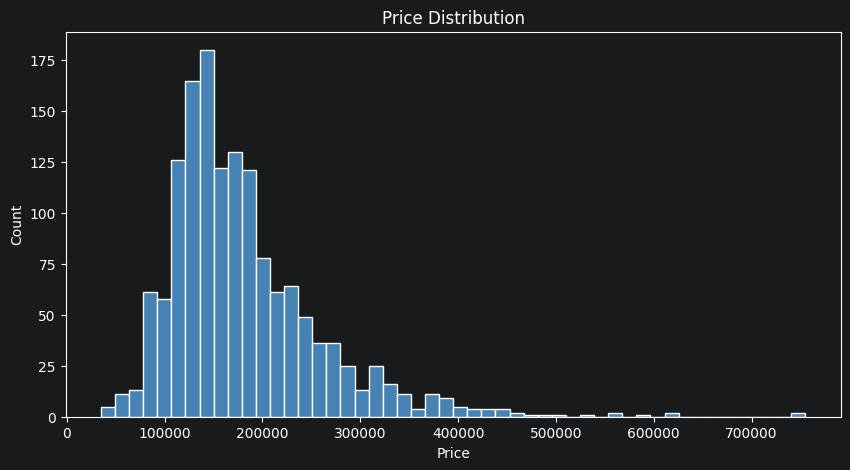

In [21]:
plt.figure(figsize=(10, 5))
plt.hist(df['Price'], bins=50, color='steelblue', edgecolor='white')
plt.xlabel('Price')
plt.ylabel('Count')
plt.title('Price Distribution')
plt.show()

The histogram shows the distribution of house prices. The distribution is right-skewed, the largest number of prices is between 100,000 USD and 250,000 USD, while a small number of expensive houses is in the right

In [22]:
avg_year = df.groupby('YrSold')['Price'].mean()
fig = px.line(x=avg_year.index, y=avg_year.values,
        labels={'x': 'Year', 'y': 'Average Price'},
        title='Average Price by Year Sold')
fig.update_xaxes(type='category')

The line chart shows average house prices from 2006 to 2010. Prices peaked in 2007 at around 186k USD, then dropped sharply to 177k USD in 2008 reflecting consequences of the global financial crisis on the mortgage market. A small recovery followed in 2009 (179k USD), but prices declined again by 2010. Overall the market showed limited volatility, with prices staying in the 177k-186k USD range throughout the period

In [23]:
avg_price = df.groupby('GenQuality')['Price'].median()
fig = px.bar(x=avg_price.index.astype(str), y=avg_price.values,
             labels={'x': 'Quality', 'y': 'Median Price'},
             title='Median Price by Quality')
fig.show()

The bar chart shows the median house prices across different categories of overall house quality, rated from 1 to 10. Prices increase steadily with each quality rating, starting at approximately 50k USD for the lowest quality (1) and rising exponentially to peak at around 430k USD for the highest quality (10). A sharp price jump is visible in the top categories, where moving from quality 8 to 10 nearly doubles the median price. Overall, the data reveals a strong positive correlation between house quality and median price, with premium-quality properties commanding significantly higher market values

In [24]:
TGarage = df['GarageType'].value_counts()
fig = px.pie(values=TGarage.values, names=TGarage.index, title='Garage Type Distribution')
fig.show()

The pie chart shows the distribution of different garage types in the dataset. Attached garages (Attchd) are by far the most common, accounting for the absolute majority at 59.6%, followed by detached garages (Detchd) at 26.5%. Built-in garages (BuiltIn) and houses with no garage (NoGarage) represent much smaller shares, making up 6.03% and 5.55% respectively. The remaining categories, including basement garages (Basment), carports (CarPort), and properties with two types of garages (2Types), combined constitute less than 3% of the total market. Overall, the vast majority of houses feature either an attached or detached garage, while other options remain rare exceptions

## Detailed Overview

In [25]:
top1 = df.groupby('Neighborhood')['Price'].median().idxmax()
last = df.groupby('Neighborhood')['Price'].median().idxmin()
df_compare = df[df['Neighborhood'].isin([top1, last])]
fig = px.box(df_compare, x='Neighborhood', y='Price',
             color='Neighborhood',
             title='Price Comparison: Rich vs Poor')
fig.show()

The boxplot compares house prices in the two most contrasting neighborhoods — NridgHt (highest median price) and MeadowV (lowest median price). The difference is significant: NridgHt houses are priced considerably higher, while MeadowV shows lower prices with less variation. This suggests that location plays a major role in determining house value

In [26]:
fig = px.scatter(df, x='LivArea', y='Price',
                 color='GenQuality',
                 title='Living Area vs Price by Quality',
                 trendline='ols')
fig.show()

The scatter plot shows the relationship between living area and price, colored by overall quality. There is a clear positive trend - larger houses cost more. Quality adds another layer: yellow and orange dots (high quality, 8-10) cluster in the upper part of the chart, while purple dots (low quality, 1-4) stay near the bottom regardless of size. This means that two houses with the same living area can have very different prices depending on build quality - size alone does not determine value

In [27]:
fig = px.box(df, x='GarageType', y='Price',
             title='Price by Garage Type',
             color='GarageType')
fig.show()

The boxplot shows the distribution of house prices for each garage type. Houses with built-in and attached garages have significantly higher median prices compared to houses with no garage or a carport. This considers that garage convenience is an important factor in house pricing. Notable outliers are present in most categories, indicating that some houses are priced much higher than the typical range for their garage type

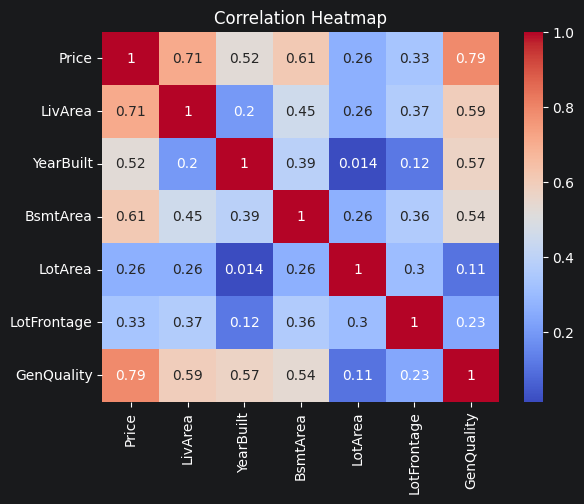

In [28]:
cols_for_cor = ['Price', 'LivArea', 'YearBuilt', 'BsmtArea', 'LotArea', 'LotFrontage', 'GenQuality']
sns.heatmap(df[cols_for_cor].corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

The heatmap shows correlations between all numerical features. The strongest correlations with Price are GenQuality (0.79) and LivArea (0.71), meaning house quality and living area are the most important factors driving the price. BsmtArea also shows a moderate correlation (0.61). LotArea and LotFrontage have the weakest correlation with price (0.26 and 0.33), considering that Lot Area alone does not determine house value

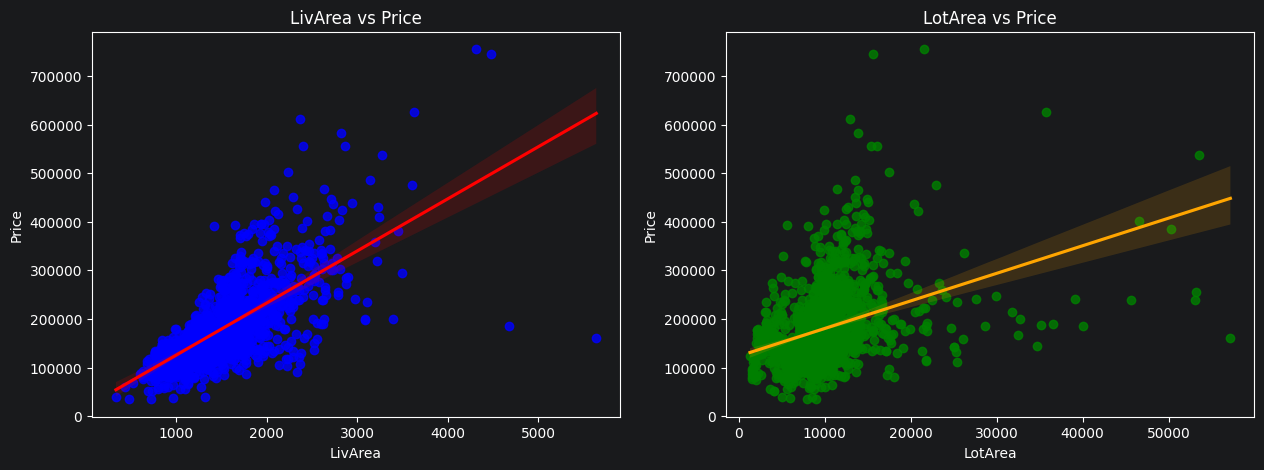

In [29]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
sns.regplot(x=df['LivArea'], y=df['Price'], line_kws={'color' : 'red'}, ax=axes[0], color='b')
axes[0].set_title('LivArea vs Price')
sns.regplot(data=df[df['LotArea'] < 60000], x='LotArea', y='Price', line_kws={'color' : 'orange'}, ax=axes[1], color='g')
axes[1].ticklabel_format(style='plain', axis='y')
axes[1].set_title('LotArea vs Price')
plt.show()

The two scatter plots compare how living area and lot area relate to price. LivArea shows a strong positive correlation, points follow the regression line closely and the confidence interval is narrow, meaning predictions are reliable. LotArea shows a much weaker relationship, points are scattered widely around the line and the confidence interval is very wide, especially for larger lots. This visually confirms that living area is a stronger predictor of price than lot size

LotArea was filtered to values below 60,000 sq ft to remove extreme outliers that distorted the regression line. These outliers represent unusually large plots that are rare in the dataset and not representative of typical houses

## Hypothesis check

### Hypothesis 1

I want to check if houses with excellent heating but small living area (below median) are priced higher than houses with average heating but large living area (above median)
- **H0**: There is no significant difference in price between the two groups
- **H1**: Houses with average heating and large area cost more than houses with excellent heating and small area

In [30]:
median_area = df['LivArea'].median()
group1 = df[(df['HeatingQC'] == 'Ex') & (df['LivArea'] < median_area)]['Price']
group2 = df[(df['HeatingQC'] == 'TA') & (df['LivArea'] > median_area)]['Price']
stat, p = ttest_ind(group1, group2)
print('Ex Heating + Small Area median:', group1.median())
print('Average Heating + Large Area median:', group2.median())
print('Counts:', len(group1), len(group2))
print('P-value:', p)

Ex Heating + Small Area median: 149950.0
Average Heating + Large Area median: 165000.0
Counts: 272 138
P-value: 6.357310225719796e-07


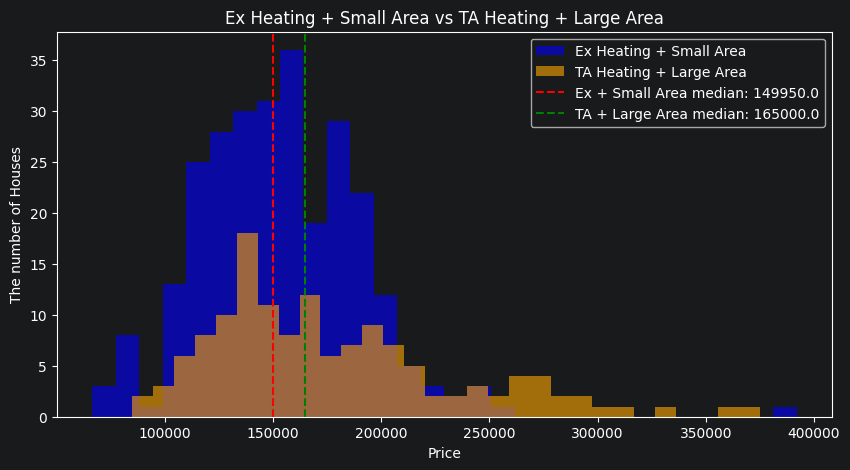

In [31]:
plt.figure(figsize=(10, 5))
plt.hist(group1, bins=30, label='Ex Heating + Small Area', color='blue', alpha=0.6)
plt.hist(group2, bins=30, label='TA Heating + Large Area', color='orange', alpha=0.6)
plt.axvline(group1.median(), color='red', linestyle='--', label=f'Ex + Small Area median: {group1.median():.1f}')
plt.axvline(group2.median(), color='green', linestyle='--', label=f'TA + Large Area median: {group2.median():.1f}')
plt.legend()
plt.xlabel('Price')
plt.ylabel('The number of Houses')
plt.title('Ex Heating + Small Area vs TA Heating + Large Area')
plt.show()

The hypothesis was confirmed. Houses with average heating (TA) but larger living area had a higher median price (165k USD compared to $149,950 USD for houses with excellent heating but smaller area). The t-test confirmed statistical significance (p = 0.0000025 < 0.05). I can suggest that living area has a stronger influence on price than heating quality, and buyers are willing to pay more for extra space even at the cost of heating comfort

### Hypothesis 2

I hypothesize that new houses (HouseAgeSold < 10) with an attached garage have a higher price per square foot than new houses with a built-in garage, despite built-in garages being considered more convenient
- **H0**: There is no significant difference in PricePerSqFt between new houses with Attchd and BuiltIn garages
- **H1**: New houses with an attached garage have a higher PricePerSqFt than new houses with a built-in garage

In [32]:
gr1 = df[(df['HouseAgeSold'] < 10) & (df['GarageType'] == 'Attchd')]['PricePerSqFt']
gr2 = df[(df['HouseAgeSold'] < 10) & (df['GarageType'] == 'BuiltIn')]['PricePerSqFt']
stat, p = ttest_ind(gr1, gr2)
print('New + Attchd median:', gr1.median())
print('New + BuiltIn median:', gr2.median())
print('Counts:', len(gr1), len(gr2))
print('P-value:', p)

New + Attchd median: 145.48
New + BuiltIn median: 118.88
Counts: 315 63
P-value: 1.8427310758744767e-08


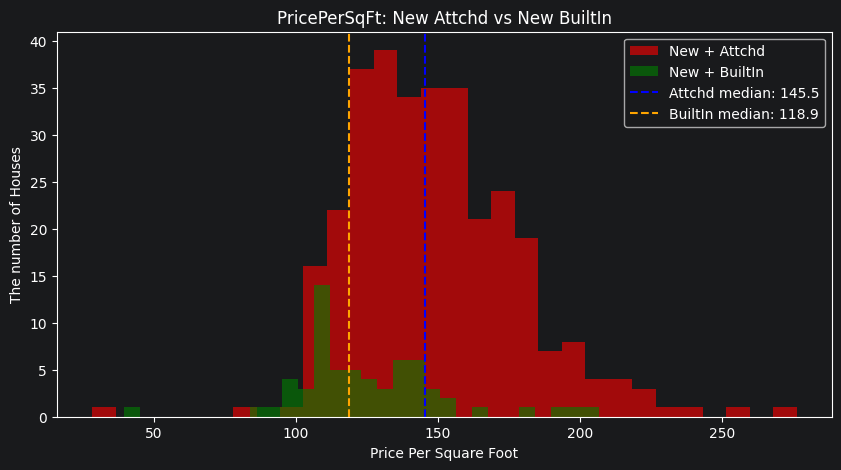

In [33]:
plt.figure(figsize=(10, 5))
plt.hist(gr1, bins=30, label='New + Attchd', color='red', alpha=0.6)
plt.hist(gr2, bins=30, label='New + BuiltIn', color='green', alpha=0.6)
plt.axvline(gr1.median(), color='blue', linestyle='--', label=f'Attchd median: {gr1.median():.1f}')
plt.axvline(gr2.median(), color='orange', linestyle='--', label=f'BuiltIn median: {gr2.median():.1f}')
plt.legend()
plt.xlabel('Price Per Square Foot')
plt.ylabel('The number of Houses')
plt.title('PricePerSqFt: New Attchd vs New BuiltIn')
plt.show()

The hypothesis was confirmed. New houses with an attached garage have a significantly higher median PricePerSqFt (145.48 USD) compared to new houses with a built-in garage (118.88 USD). The t-test confirmed statistical significance (p-value = 0.009 < 0.05). This is a non-obvious result despite built-in garages being more convenient, attached garage houses require a higher price per square foot. I can suggest that other factors such as area or neighborhood drive the price difference rather than garage type alone

## Machine Learning

In [34]:
X1 = df[['LivArea', 'LotArea', 'BsmtArea', 'HouseAgeSold', 'Neighborhood', 'GarageType', 'GenQuality']]
y1 = df['Price']
cat_features = ['Neighborhood', 'GarageType', 'GenQuality']
X_train1, X_test1, y_train1, y_test1 = train_test_split(X1, y1, test_size=0.2, random_state=42)
model = CatBoostRegressor(iterations=500, learning_rate=0.05, depth=8, verbose=50)
model.fit(X_train1, y_train1, cat_features=cat_features)
predictions = model.predict(X_test1)
MAE = mean_absolute_error(y_test1, predictions)
MeanPrice = df['Price'].mean()
print(f'Mean Price: {MeanPrice:.3f}')
print(f'Mean Absolute Error of the Model: {MAE:.3f}')
print(f'Error in percentage: {(MAE / MeanPrice * 100):.1f} %')

0:	learn: 74875.7741401	total: 57.9ms	remaining: 28.9s
50:	learn: 28190.5418310	total: 142ms	remaining: 1.25s
100:	learn: 21898.3954487	total: 229ms	remaining: 905ms
150:	learn: 19230.3530972	total: 313ms	remaining: 723ms
200:	learn: 17460.8785084	total: 402ms	remaining: 598ms
250:	learn: 16053.5280233	total: 488ms	remaining: 484ms
300:	learn: 14760.9022585	total: 584ms	remaining: 386ms
350:	learn: 13662.9787498	total: 689ms	remaining: 292ms
400:	learn: 12773.5748401	total: 789ms	remaining: 195ms
450:	learn: 12022.0385306	total: 884ms	remaining: 96ms
499:	learn: 11411.9707263	total: 982ms	remaining: 0us
Mean Price: 180921.196
Mean Absolute Error of the Model: 16653.773
Error in percentage: 9.2 %


For the machine learning, I used CatBoostRegressor, a Yandex's gradient boosting algorithm. I have chosen it because of the Ordered Target Encoding that handles categorical features natively, and so there is no need to encode columns like Neighborhood, GarageType and GenQuality manually.
The model was trained on 7 features: LivArea, LotArea, BsmtArea, HouseAgeSold, Neighborhood, GarageType and GenQuality. The dataset was split 80/20, where 80% for training and 20% for testing

I manually tuned the hyperparameters: iterations, learning rate and depth of trees to minimize the error. By increasing iterations to 500 and decreasing learning rate to 0.05, I achieved the best result of 9.2%, meaning on average the model's prediction is off by about $16,653 on a mean house price of 180,921 USD

## Discussion

Well, in this project I looked at the Housing Dataset and here's what I found:
- The dataset had missing values in LotFrontage (17.7%) and GarageType (5.5%), which were filled with median and "No Garage" respectively
- GenQuality and LivArea are the strongest predictors of price — correlations of 0.79 and 0.71. LotArea barely matters (0.26)
- Hypothesis 1 (houses with average heating but large area cost more than houses with excellent heating but small area) did hold — living area beats heating quality
- Hypothesis 2 (new houses with attached garage have higher PricePerSqFt than new houses with built-in garage) did hold — an unexpected result since built-in garages are more convenient
- CatBoostRegressor predicted house prices with 9.2% error — on average off by $16,653

Also, I highlighted that:
 - The 2008 financial crisis had a visible impact on the housing market. Average prices dropped from 186k USD in 2007 to 177k USD in 2008 and never fully recovered within the dataset period
  - On the American housing market, buyers value living area significantly more than total plot size. LivArea correlation with price is 0.71 while LotArea is only 0.26. People pay for the space inside the house, not the land around it